# Module 7 - Outlier Analysis

Outlier analysis focuses on identifying unusual observations that are significantly different from most of the data.

This notebook uses the Hotel Booking Demand dataset to detect and evaluate outliers using statistical methods and visualizations.

## 1. Setup and Data Load

The required libraries are imported and the Hotel Booking Demand dataset is loaded for outlier analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/hotel_bookings.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Interpretation

The dataset is loaded into a Pandas DataFrame and the first few records are displayed.

### Findings

The dataset contains booking-related numerical features that can be examined for unusual or extreme observations.

### AI/ML Relevance

Outlier analysis is important before Machine Learning because extreme or incorrect values can influence statistical analysis and model behavior.

## 2. What is an Outlier?

An outlier is a data value that is significantly different from most of the other values in a dataset.

Outliers can occur because of data-entry errors, unusual events, or genuine observations.

### Example

In the Hotel Booking Demand dataset, a booking with an unusually high lead time compared with most other bookings may be considered an outlier.

### Real-World Example

A hotel may receive an unusually large booking for a special event. Although the value is different from normal bookings, it may still be a genuine observation.

### AI/ML Relevance

Outliers can affect statistical calculations and Machine Learning models, so they should be identified and evaluated before deciding how to handle them.

## 3. Why Outliers Occur

Outliers can occur for different reasons. They may result from data-entry errors, measurement problems, unusual events, or genuine values that are different from the majority of observations.

### Common Reasons

- Data-entry or recording errors
- Measurement or system errors
- Unusual or rare events
- Natural variation in the data
- Genuine extreme observations

### Example

In the Hotel Booking Demand dataset, an unusually high number of days between booking and arrival may occur because a customer made a reservation far in advance.

### Real-World Example

A hotel may receive a very large group booking for a special event. Although the booking is unusual compared with regular bookings, it may be a valid observation.

### AI/ML Relevance

Understanding why an outlier occurs helps decide whether it should be removed, transformed, or retained before Machine Learning.

## 4. Types of Outliers

Outliers can be classified based on how they differ from the other observations.

### 4.1 Univariate Outliers

A univariate outlier is an unusual value identified by analyzing one variable at a time.

Example:

A hotel booking with an unusually high lead time compared with most other bookings may be a univariate outlier.

### 4.2 Multivariate Outliers

A multivariate outlier is an observation that appears unusual when two or more variables are considered together.

Example:

A booking may have a normal lead time but an unusually high average daily rate combined with an unusually long stay.

### AI/ML Relevance

Understanding different types of outliers helps select suitable detection methods and evaluate unusual observations before Machine Learning.

## 5. IQR Method

The IQR (Interquartile Range) method is used to identify potential outliers in a numerical variable.

IQR is calculated as:

IQR = Q3 - Q1

The lower bound is:

Q1 - 1.5 × IQR

The upper bound is:

Q3 + 1.5 × IQR

Values below the lower bound or above the upper bound are considered potential outliers.

### Example

The IQR method can be applied to the lead_time variable to identify bookings with unusually low or high lead times.

### Real-World Example

A hotel may have a small number of bookings made much earlier than the normal booking period. These values can be identified using the IQR method.

### AI/ML Relevance

The IQR method helps detect potential outliers without assuming that the data follows a normal distribution.

### Implementation

In [2]:
Q1 = df["lead_time"].quantile(0.25)
Q3 = df["lead_time"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["lead_time"] < lower_bound) |
    (df["lead_time"] > upper_bound)
]

print("Number of potential outliers:", len(outliers))
print("Lower Bound:", round(lower_bound, 2))
print("Upper Bound:", round(upper_bound, 2))

Number of potential outliers: 3005
Lower Bound: -195.0
Upper Bound: 373.0


### Interpretation

The output shows the IQR boundaries and the number of observations that fall outside the expected range.

### Observation

The identified values are potential outliers and should be examined further before deciding whether they are genuine observations or errors.

### AI/ML Relevance

IQR-based detection is useful for identifying unusual numerical observations during data exploration and preprocessing.

## 6. Z-Score Method

The Z-score method is used to identify potential outliers by measuring how far a value is from the mean in terms of standard deviations.

A Z-score is calculated as:

Z = (X - Mean) / Standard Deviation

A commonly used rule is that values with an absolute Z-score greater than 3 can be considered potential outliers.

### Example

The Z-score method can be applied to the adr variable to identify unusually high or low average daily rates.

### Real-World Example

A hotel may have a small number of bookings with room rates that are much higher or lower than the typical rate.

### AI/ML Relevance

The Z-score method helps identify extreme numerical values and is useful when the data is approximately normally distributed.

### Implementation

In [3]:
from scipy.stats import zscore

z_scores = zscore(df["adr"].dropna())

outliers = df.loc[df["adr"].dropna().index[abs(z_scores) > 3]]

print("Number of potential outliers:", len(outliers))
print(outliers[["hotel", "adr"]].head())

Number of potential outliers: 1138
            hotel     adr
803  Resort Hotel  280.74
925  Resort Hotel  268.00
936  Resort Hotel  267.00
943  Resort Hotel  277.50
973  Resort Hotel  276.43


### Interpretation

The output shows the observations whose Z-score is greater than 3 or less than -3.

### Observation

These observations are considered potential outliers and should be examined using the business context before deciding how to handle them.

### AI/ML Relevance

Z-score analysis helps identify extreme numerical values that may influence statistical analysis and Machine Learning models.

### 7. Box Plot

A box plot is a graphical representation of numerical data that shows the median, quartiles, spread, and potential outliers.

### Example

A box plot can be used to identify unusual values in the adr variable of the Hotel Booking Demand dataset.

### Real-World Example

A hotel can use a box plot to identify bookings with unusually high or low daily room rates.

### AI/ML Relevance

Box plots are useful during EDA for detecting potential outliers and understanding the spread of numerical features.

### Implementation

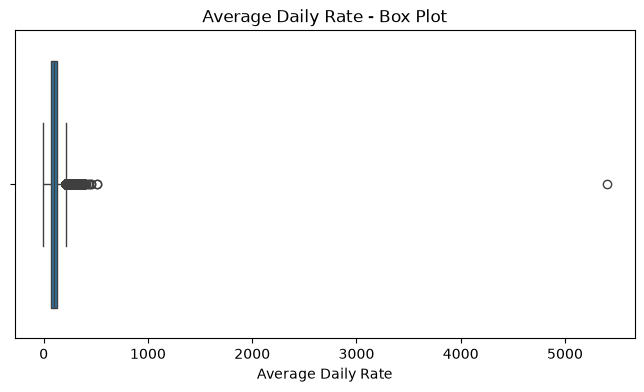

In [4]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["adr"])

plt.title("Average Daily Rate - Box Plot")
plt.xlabel("Average Daily Rate")
plt.show()

### Interpretation

The box plot shows the median, quartiles, and potential outliers in the average daily rate.

### Observation

Values that appear beyond the whiskers are potential outliers and should be investigated further.

### AI/ML Relevance

Box plots help identify extreme observations before deciding whether they should be retained, transformed, or removed.

### 8. Scatter Plot

A scatter plot shows the relationship between two numerical variables using individual data points.

### Example

A scatter plot can be used to examine the relationship between lead time and average daily rate in the Hotel Booking Demand dataset.

### Real-World Example

A hotel can use a scatter plot to check whether bookings made further in advance are associated with higher or lower room rates.

### AI/ML Relevance

Scatter plots help identify relationships, trends, clusters, and unusual observations between numerical variables.

### Implementation

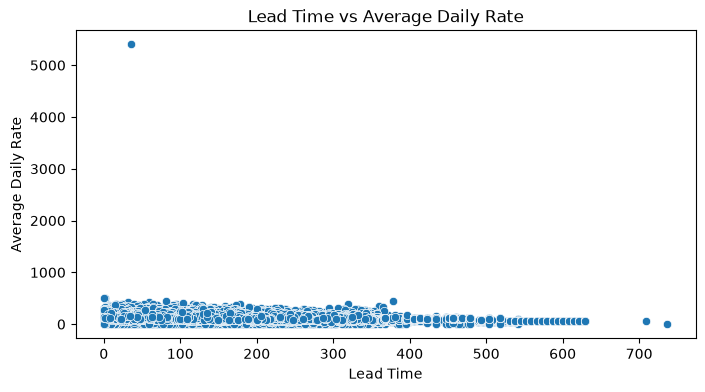

In [5]:
plt.figure(figsize=(8, 4))

sns.scatterplot(data=df, x="lead_time", y="adr")

plt.title("Lead Time vs Average Daily Rate")
plt.xlabel("Lead Time")
plt.ylabel("Average Daily Rate")
plt.show()

### Interpretation

The scatter plot shows how average daily rate varies across different lead times.

### Observation

The distribution of points helps identify whether there is a clear relationship or unusual observations between the two variables.

### AI/ML Relevance

Scatter plots help understand numerical relationships and can support further outlier analysis and feature selection.

## 9. Outlier Evaluation

Identified outliers should be examined based on their values and business context before deciding how to handle them.

An outlier may be a genuine observation, a data-entry error, or an unusual but valid observation.

### 9.1 Genuine Observation

A genuine observation is an unusual value that correctly represents a real booking.

### 9.2 Data-Entry Error

A data-entry error occurs when an incorrect value is recorded in the dataset.

### 9.3 Unusual but Valid Observation

Some extreme values may be unusual but still represent valid hotel bookings.

### 9.4 Should It Be Removed?

An outlier should only be removed when there is sufficient evidence that it is incorrect or harmful to the analysis.

### 9.5 Should It Be Transformed?

Transformation may be considered when extreme values are valid but create a highly skewed distribution.

### 9.6 Should It Be Retained?

A valid observation should generally be retained when it represents a real situation in the dataset.

### Implementation

In [6]:
Q1 = df["adr"].quantile(0.25)
Q3 = df["adr"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

outliers = df[df["adr"] > upper_bound]

print("Potential ADR outliers:", len(outliers))
print(outliers[["hotel", "adr"]].head(10))

Potential ADR outliers: 3793
            hotel     adr
140  Resort Hotel  225.00
303  Resort Hotel  213.75
396  Resort Hotel  230.67
412  Resort Hotel  216.13
523  Resort Hotel  249.00
526  Resort Hotel  241.50
558  Resort Hotel  214.00
580  Resort Hotel  214.00
584  Resort Hotel  240.64
632  Resort Hotel  217.05


### Reasoning

The detected ADR values are potential outliers based on the IQR method.

They should not be removed automatically because a high daily rate may represent a genuine booking, such as a premium room or a high-demand period.

The values should be reviewed with business context before deciding whether to retain, transform, or remove them.

### AI/ML Relevance

Evaluating outliers carefully helps preserve useful information while reducing the impact of incorrect or extreme values on Machine Learning models.

## 10. Reasoning and Conclusion

Outlier detection methods help identify unusual observations, but an outlier is not always an error.

The identified observations should be evaluated using statistical results and the business context of the Hotel Booking Demand dataset.

- Genuine observations should be retained.
- Data-entry errors may need to be corrected or removed.
- Unusual but valid observations should generally be retained.
- Transformation can be considered when valid extreme values create a highly skewed distribution.
- Removal should only be performed when there is sufficient evidence that the value is incorrect.

### Conclusion

Outlier handling should be based on the reason behind the unusual value rather than only on statistical thresholds.

The IQR method, Z-score method, box plot, and scatter plot provide useful ways to identify potential outliers, while business context helps determine the appropriate treatment.